In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
iris=load_iris()
df=pd.DataFrame(iris.data, columns=iris.feature_names)
df['species']=iris.target
df['species_name']=df['species'].map({0:'setosa', 1:'versicolor',2:'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [18]:
print("Shape:",df.shape)
print("\nData types:\n",df.dtypes)
print("\nMissing values:\n",df.isnull().sum())

Shape: (150, 6)

Data types:
 sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


In [19]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


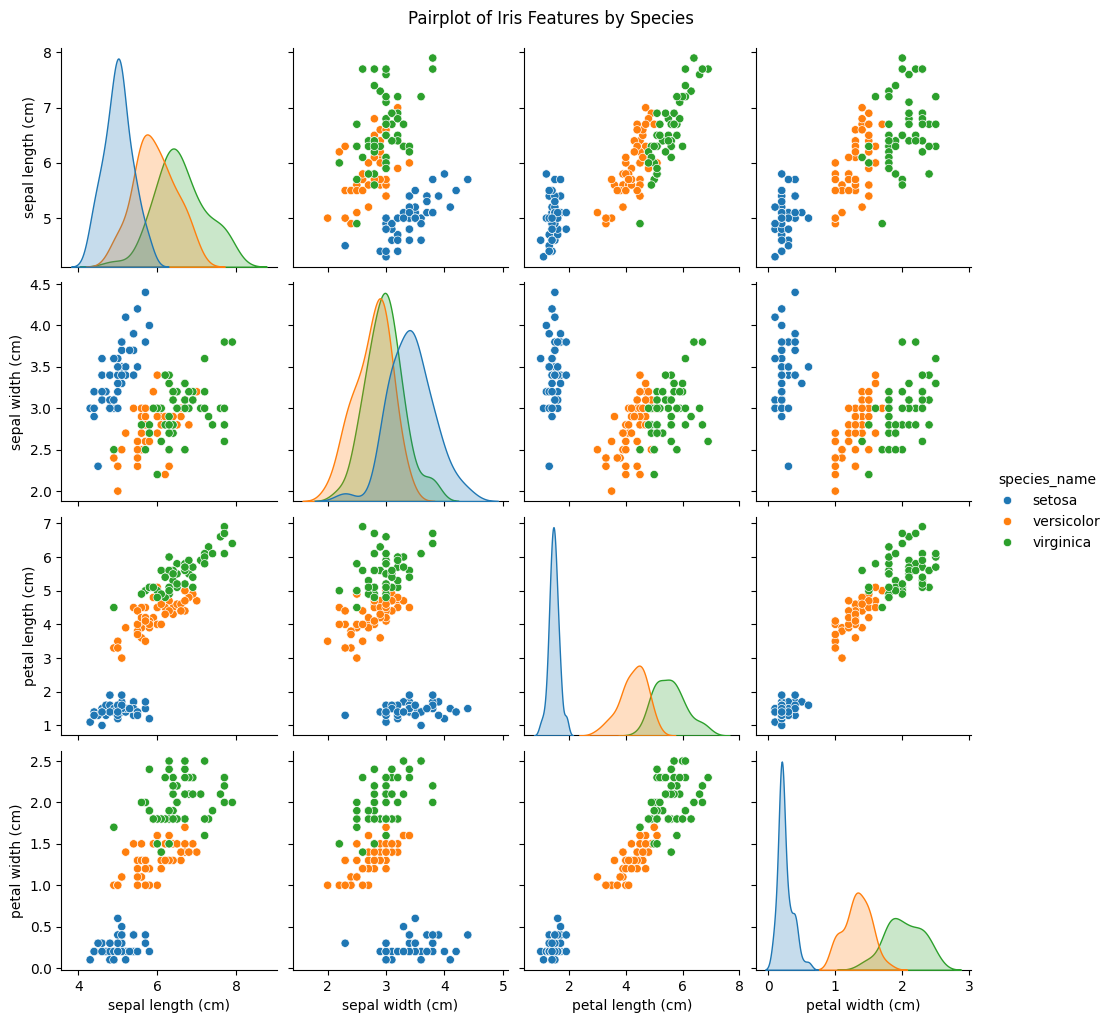

In [20]:
sns.pairplot(df, hue='species_name', vars =iris.feature_names)
plt.suptitle("Pairplot of Iris Features by Species",y=1.02)
plt.show()

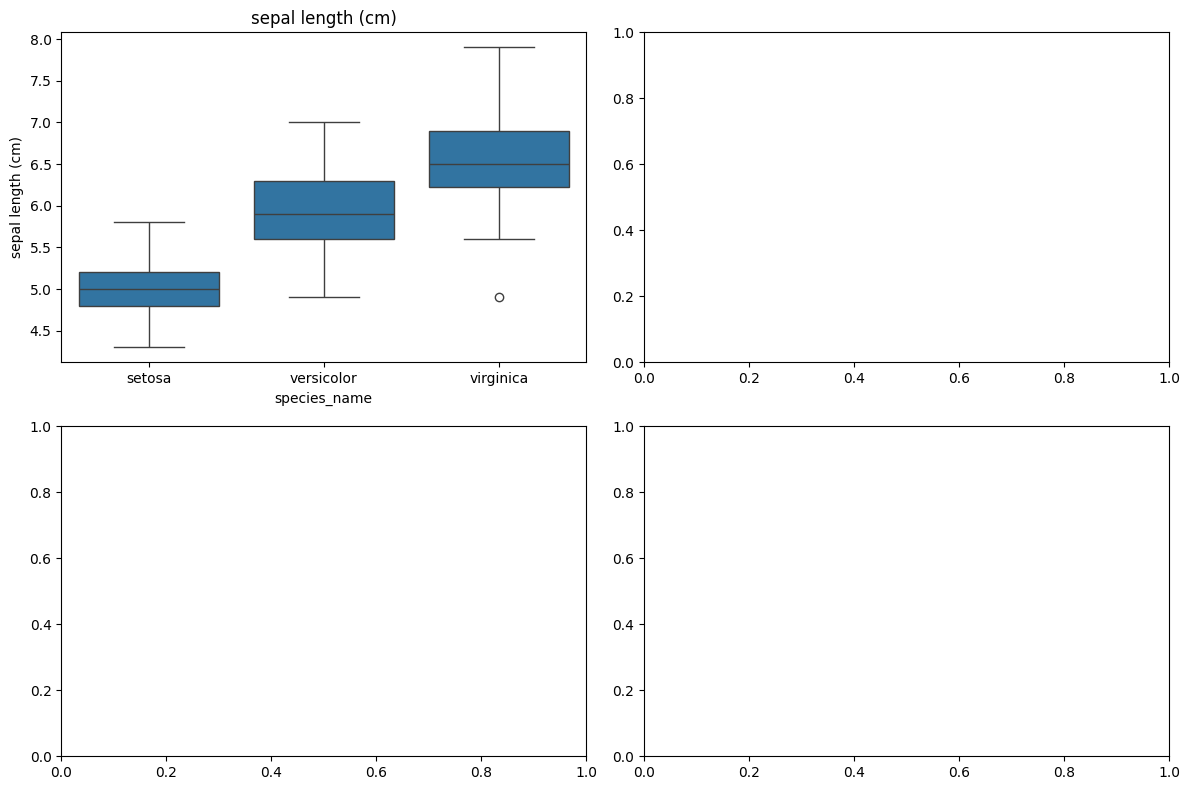

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [21]:
fig, axes=plt.subplots(2,2,figsize=(12,8))
for ax, feature in zip(axes.flatten(),iris.feature_names):
  sns.boxplot(data=df, x='species_name', y=feature, ax=ax)
  ax.set_title(feature)
  plt.tight_layout()
  plt.show()

<Figure size 640x480 with 0 Axes>

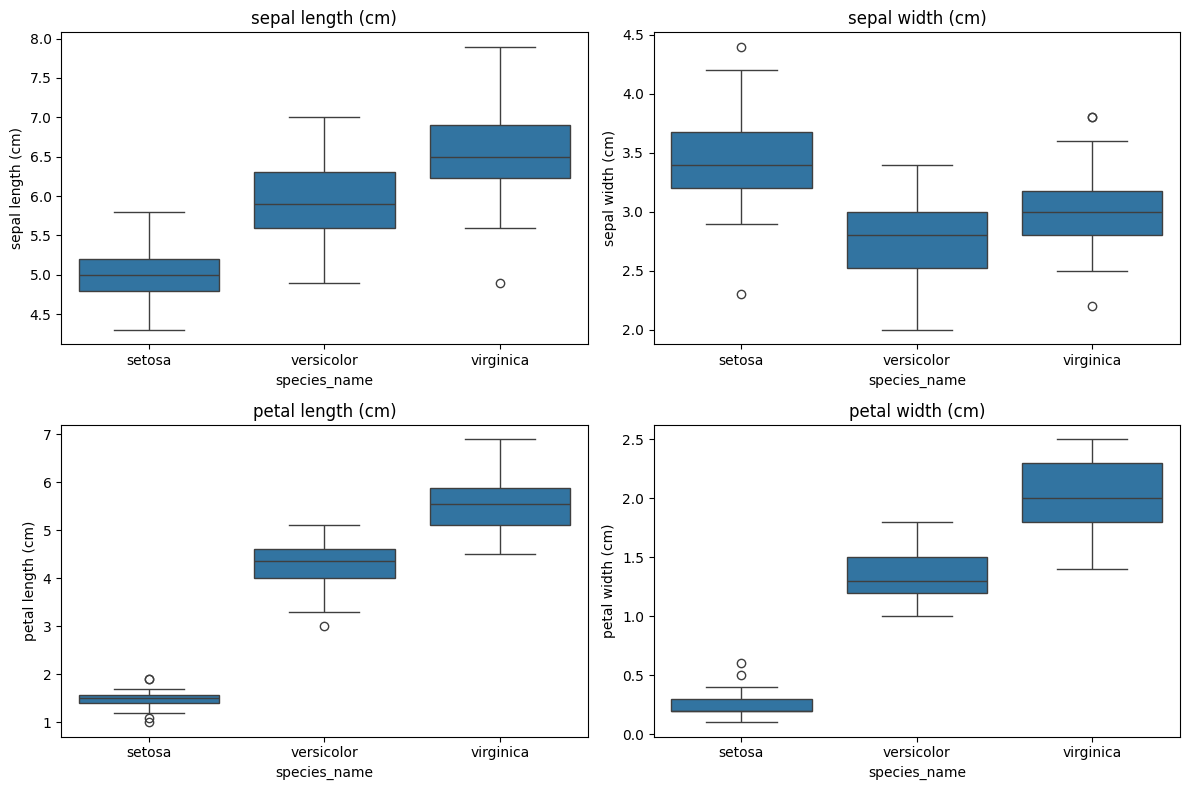

In [22]:
plt.figure()
fig, axes= plt.subplots(2,2,figsize=(12,8))
features=iris.feature_names
for ax,feature in zip(axes.flatten(),features):
  sns.boxplot(data=df,x='species_name',y=feature,ax=ax)
  ax.set_title(feature)
plt.tight_layout()
plt.show()

## Feature Selection Discussion
Petal length and petal width show the clearest separation between species, with minimal overlap betrween boxes. Sepal length is moderately useful.This suggests petal measurements will drive most of the classification power.

In [23]:
from sklearn.model_selection import train_test_split
X=df[iris.feature_names]
y=df['species']
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
    )
print("Train size:",X_train.shape,"Test size:",X_test.shape)

Train size: (120, 4) Test size: (30, 4)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
lr_model=LogisticRegression(max_iter=200)
lr_model.fit(X_train,y_train)
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,y_train)
print("Both models trained.")

Both models trained.


In [25]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
pred_lr=lr_model.predict(X_test)
pred_knn=knn_model.predict(X_test)
print("=== Logistic Regression ===")
print("Accuracy:",accuracy_score(y_test,pred_lr))
print(confusion_matrix(y_test,pred_lr))
print(classification_report(y_test,pred_lr,target_names=iris.target_names))
print("\n=== KNN ===")
print("Accuracy:",accuracy_score(y_test,pred_knn))
print(confusion_matrix(y_test,pred_knn))
print(classification_report(y_test,pred_knn,target_names=iris.target_names))

=== Logistic Regression ===
Accuracy: 0.9666666666666667
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


=== KNN ===
Accuracy: 1.0
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



##Conclusion
Both models performed strongly on this dataset. Logistic Regression achieved 96.7% accuracy, misclassifying one versicolor sample as virginica. KNN(k=5) achieved 100% accuracy with zero misclassification.
Based on these results, KNN is the best-performing model on this test set. This is expected given the Iris dataset's strong class separation- especially on petal length and petal width, as seen in the earlier box plots- which favours distance-based methods like KNN.